# Wildlife Trade Analysis and Exploratory Forecasting

## Project Context

This notebook reorganizes the reproducible trade-analysis and PCA components of a team research project on wildlife-trade monitoring. It uses supplied CITES Wildlife TradeView aggregates. The data describe filtered reported trade quantities; they do not by themselves identify illegal transactions.

## Research Question

What patterns are visible in the supplied trade-term, taxonomic, and annual source summaries, and what can a small exploratory time-series model show about the uncertainty of extrapolation?

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA

RANDOM_SEED = 2024
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "terms": DATA_DIR / "cites_term_2014_2023.csv",
    "source": DATA_DIR / "cites_source_2014_2023.csv",
    "taxonomy": DATA_DIR / "cites_taxonomic_group_2014_2023.csv",
}
missing_files = [str(path.relative_to(PROJECT_ROOT)) for path in FILES.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Required data files are missing: " + ", ".join(missing_files)
        + ". See data/README.md for filenames, fields, and source guidance."
    )

## Data

The three files summarize trade by term, source and year, and taxonomic group. Before analysis, the notebook verifies required fields, reports missingness and duplicates, and converts quantities to numeric values. Missing biological classifications are labeled `Unknown`; they are not guessed.

In [2]:
terms = pd.read_csv(FILES["terms"])
source = pd.read_csv(FILES["source"])
taxonomy_raw = pd.read_csv(FILES["taxonomy"])

required_fields = {
    "terms": {"Ranking", "Term", "Quantity", "Filters"},
    "source": {"Ranking", "Source", "Code", "Filters", *map(str, range(2014, 2024))},
    "taxonomy": {
        "Ranking", "Taxonomic Group", "Quantity", "Kingdom", "Phylum", "Class",
        "Order", "Family", "Genus", "Taxon", "Filters",
    },
}
frames = {"terms": terms, "source": source, "taxonomy": taxonomy_raw}
for name, frame in frames.items():
    missing = sorted(required_fields[name] - set(frame.columns))
    if missing:
        raise ValueError(f"{name} is missing required fields: {missing}")

quality_rows = []
for name, frame in frames.items():
    quality_rows.append(
        {
            "dataset": name,
            "rows": len(frame),
            "columns": frame.shape[1],
            "duplicate_rows": int(frame.duplicated().sum()),
            "missing_cells": int(frame.isna().sum().sum()),
        }
    )
display(pd.DataFrame(quality_rows))

missing_taxonomy = taxonomy_raw[["Order", "Family", "Genus"]].isna().sum().rename("missing_values")
display(missing_taxonomy.to_frame())

,dataset,rows,columns,duplicate_rows,missing_cells
0,terms,51,4,0,0
1,source,1,14,0,0
2,taxonomy,501,11,0,18


,missing_values
Order,1
Family,5
Genus,12


In [3]:
terms = terms.copy()
taxonomy = taxonomy_raw.copy()
terms["Quantity"] = pd.to_numeric(terms["Quantity"], errors="raise")
taxonomy["Quantity"] = pd.to_numeric(taxonomy["Quantity"], errors="raise")
taxonomy[["Order", "Family", "Genus"]] = taxonomy[["Order", "Family", "Genus"]].fillna("Unknown")

year_columns = [str(year) for year in range(2014, 2024)]
wild_rows = source.loc[source["Code"].astype(str).str.upper().eq("W")]
if len(wild_rows) != 1:
    raise ValueError(f"Expected one wild-source row with Code='W'; found {len(wild_rows)}.")
annual_quantity = pd.to_numeric(wild_rows.iloc[0][year_columns], errors="raise")
annual_quantity.index = annual_quantity.index.astype(int)
annual_quantity.name = "reported_quantity"

analysis_series = annual_quantity.loc[2014:2022]
print(f"Forecast fitting window: {analysis_series.index.min()}–{analysis_series.index.max()} ({len(analysis_series)} observations)")
print(f"Reported 2023 value, shown but excluded from fitting: {annual_quantity.loc[2023]:,.0f}")
print("Filter metadata:")
print(str(wild_rows.iloc[0]["Filters"]))

Forecast fitting window: 2014–2022 (9 observations)
Reported 2023 value, shown but excluded from fitting: 0
Filter metadata:
Reported by exporter; Date range - 2014 - 2023; Unit - Number of specimens; Origin - Direct; Source - W; Taxonomic group - Mammals; 


## Methods: Descriptive Analysis

Quantities are ranked by trade term and taxonomic order. Because the distribution is strongly skewed, charts use a logarithmic quantity scale where appropriate. Aggregates represent the supplied filtered export and should not be interpreted as prevalence estimates for illegal trade.

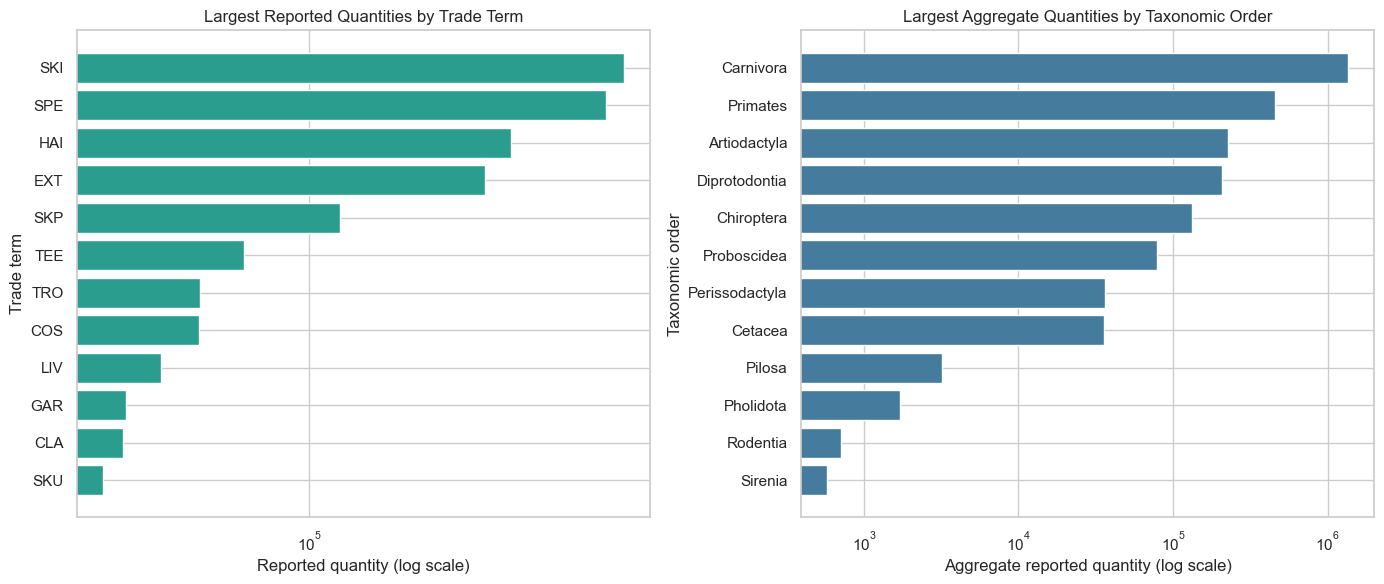

Share of total quantity in the ten largest taxonomic records: 74.28%


,Order,total_quantity,record_count
1,Carnivora,1356369,94
8,Primates,458156,190
0,Artiodactyla,226752,62
4,Diprotodontia,207836,5
3,Chiroptera,132704,18
9,Proboscidea,78702,4
5,Perissodactyla,36533,13
2,Cetacea,35567,92
7,Pilosa,3218,4
6,Pholidota,1713,8


In [4]:
top_terms = terms.nlargest(12, "Quantity").sort_values("Quantity")
order_summary = (
    taxonomy.groupby("Order", as_index=False)
    .agg(total_quantity=("Quantity", "sum"), record_count=("Quantity", "size"))
    .sort_values("total_quantity", ascending=False)
)
top_orders = order_summary.head(12).sort_values("total_quantity")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_terms["Term"], top_terms["Quantity"], color="#2a9d8f")
axes[0].set_xscale("log")
axes[0].set_title("Largest Reported Quantities by Trade Term")
axes[0].set_xlabel("Reported quantity (log scale)")
axes[0].set_ylabel("Trade term")

axes[1].barh(top_orders["Order"], top_orders["total_quantity"], color="#457b9d")
axes[1].set_xscale("log")
axes[1].set_title("Largest Aggregate Quantities by Taxonomic Order")
axes[1].set_xlabel("Aggregate reported quantity (log scale)")
axes[1].set_ylabel("Taxonomic order")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_trade_descriptive_summary.png", dpi=180, bbox_inches="tight")
plt.show()

top_record_share = 100 * taxonomy.nlargest(10, "Quantity")["Quantity"].sum() / taxonomy["Quantity"].sum()
print(f"Share of total quantity in the ten largest taxonomic records: {top_record_share:.2f}%")
display(order_summary.head(10))

## Methods: Principal Component Analysis

PCA is applied to four standardized order-level descriptors: record count, total quantity, median quantity, and maximum quantity. The input is an aggregate summary constructed from the supplied taxonomic export. PCA describes covariance among these features; it does not reveal causal relationships or species-level ecology.

Explained variance ratio: [0.665 0.26 ]


,PC1,PC2
record_count,-0.511,-0.353
total_quantity,-0.606,0.019
median_quantity,-0.152,0.934
maximum_quantity,-0.590,0.045


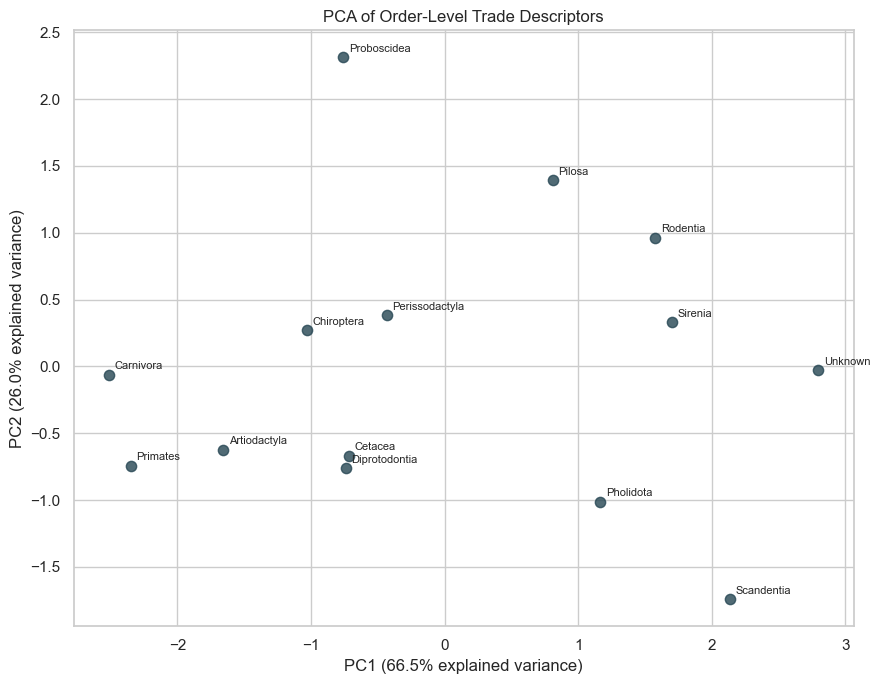

In [5]:
pca_features = (
    taxonomy.groupby("Order")
    .agg(
        record_count=("Quantity", "size"),
        total_quantity=("Quantity", "sum"),
        median_quantity=("Quantity", "median"),
        maximum_quantity=("Quantity", "max"),
    )
    .sort_index()
)
scaled_features = StandardScaler().fit_transform(np.log1p(pca_features))
pca = PCA(n_components=2, random_state=RANDOM_SEED)
scores = pca.fit_transform(scaled_features)
pca_scores = pd.DataFrame(scores, index=pca_features.index, columns=["PC1", "PC2"])
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features.columns,
    columns=["PC1", "PC2"],
)

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
display(loadings.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(pca_scores["PC1"], pca_scores["PC2"], s=55, alpha=0.8, color="#264653")
for label, row in pca_scores.iterrows():
    ax.annotate(label, (row["PC1"], row["PC2"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set_title("PCA of Order-Level Trade Descriptors")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} explained variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} explained variance)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_pca_order_level.png", dpi=180, bbox_inches="tight")
plt.show()

## Methods: Exploratory Forecasting

An ARIMA(1,1,0) model is fitted to the nine nonzero annual observations from 2014–2022. The reported 2023 zero is displayed separately but excluded because it may be an incomplete period. With only nine fitting observations, forecasts and intervals are highly unstable and are included only as a transparent demonstration.

,forecast,lower_95,upper_95
year,,,
2023,109832.0,-59616.0,279281.0
2024,84936.0,-105385.0,275257.0
2025,97100.0,-131764.0,325964.0
2026,91157.0,-161630.0,343944.0
2027,94061.0,-184490.0,372611.0


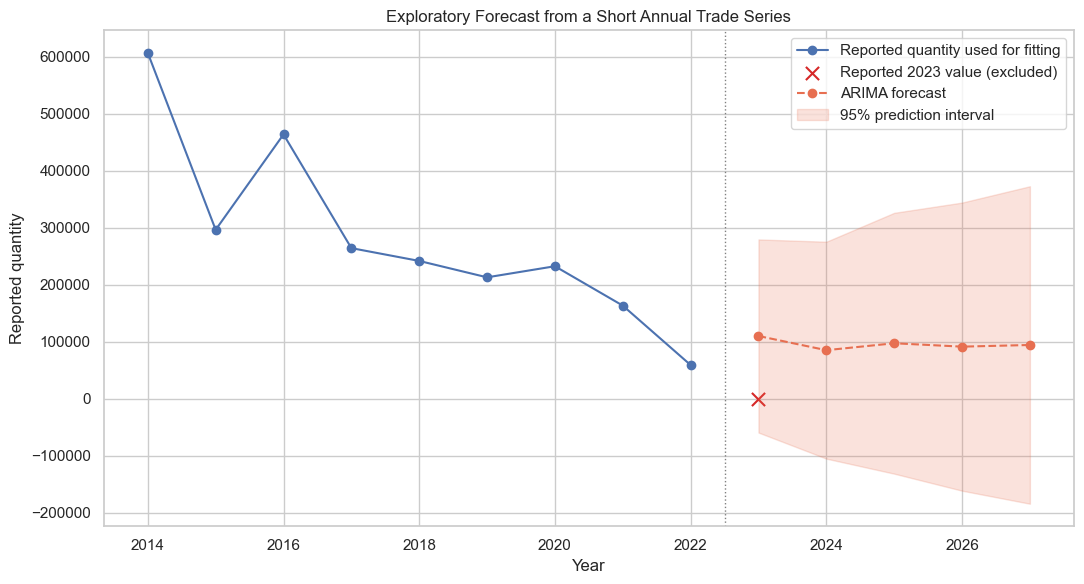

In [6]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    arima_result = ARIMA(analysis_series.astype(float), order=(1, 1, 0)).fit()
    forecast_result = arima_result.get_forecast(steps=5)
forecast_years = pd.Index(range(2023, 2028), name="year")
forecast_mean = pd.Series(forecast_result.predicted_mean.to_numpy(), index=forecast_years, name="forecast")
forecast_interval = forecast_result.conf_int(alpha=0.05)
forecast_interval.index = forecast_years
forecast_interval.columns = ["lower_95", "upper_95"]
forecast_table = pd.concat([forecast_mean, forecast_interval], axis=1)
display(forecast_table.round(0))

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(analysis_series.index, analysis_series.values, marker="o", label="Reported quantity used for fitting")
ax.scatter([2023], [annual_quantity.loc[2023]], color="#d62828", marker="x", s=90, label="Reported 2023 value (excluded)")
ax.plot(forecast_mean.index, forecast_mean.values, marker="o", linestyle="--", color="#e76f51", label="ARIMA forecast")
ax.fill_between(
    forecast_years.to_numpy(),
    forecast_interval["lower_95"].to_numpy(),
    forecast_interval["upper_95"].to_numpy(),
    color="#e76f51",
    alpha=0.2,
    label="95% prediction interval",
)
ax.axvline(2022.5, color="gray", linestyle=":", linewidth=1)
ax.set_title("Exploratory Forecast from a Short Annual Trade Series")
ax.set_xlabel("Year")
ax.set_ylabel("Reported quantity")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_exploratory_arima_forecast.png", dpi=180, bbox_inches="tight")
plt.show()

## Results

The executed tables and figures above provide the reproducible results. The distribution is concentrated, PCA summarizes correlated order-level descriptors, and the forecast interval is wide relative to the short historical series. These outputs are descriptive and exploratory.

## Limitations

- The exports are filtered aggregates, not transaction-level observations.
- Reported trade is not equivalent to illegal trade.
- Missing classifications are labeled `Unknown` and not biologically inferred.
- The 2023 zero may be incomplete; excluding it is a documented analytical choice.
- Nine annual observations are insufficient for a validated forecasting system.
- The analysis does not control for reporting practices, policy changes, enforcement effort, or ecological conditions.

## Takeaways

The supplied CITES summaries support a transparent descriptive portfolio analysis. They do not support causal claims, validated enforcement forecasts, or a turtle-specific prevalence estimate. Future work requires transaction-level provenance, complete reporting periods, explicit outcome definitions, and external validation.